In [ ]:
from keras.datasets.cifar10 import load_data
import matplotlib.pyplot as plt

(trainX, trainy), (testX, testy) = load_data()

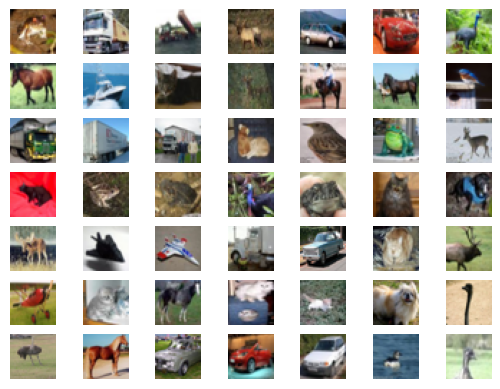

In [ ]:
for i in range(49):
  plt.subplot(7,7,1+i)
  plt.axis('off')
  plt.imshow(trainX[i])
plt.show()

In [ ]:
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Dense, Conv2D, Flatten, Dropout, LeakyReLU
#from keras.utils.vis_utils import plot_model
import numpy as np

In [ ]:
def define_discriminator(in_shape=(32,32,3)):
  model = Sequential()

  model.add(Conv2D(64, (3,3), padding='same', input_shape=in_shape))
  model.add(LeakyReLU(alpha=0.2))

  model.add(Conv2D(128, (3,3), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  model.add(Conv2D(128, (3,3), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  model.add(Conv2D(256, (3,3), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  model.add(Flatten())
  model.add(Dropout(0.4))
  model.add(Dense(1, activation='sigmoid'))

  opt = Adam(learning_rate=0.0002, beta_1=0.5)
  model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
  return model


In [ ]:
model = define_discriminator()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,497 (1.99 MB)

 Trainable params: 522,497 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def load_real_samples():
  (trainX, _), (_, _) = load_data()
  trainX.astype('float32')
  #Scale data 0-255 to -1 to 1
  trainX = (trainX - 127.5) / 127.5
  return trainX

In [ ]:
#X00 = load_real_samples()
#X00[0].shape

In [ ]:
def generate_real_samples(datasets,n_samples):
  #trainX = load_real_samples()
  ix = np.random.randint(0, datasets.shape[0], n_samples)
  X = datasets[ix]
  y = np.ones((n_samples, 1))
  return X, y

In [ ]:
def generate_fake_sample(n_samples):
  X = np.random.rand(32*32*3 * n_samples)
  #covert -1 to 1
  X = -1 + X * 2
  X = X.reshape((n_samples, 32, 32, 3))
  y = np.zeros((n_samples, 1))
  return X,y

In [ ]:
def train_discriminator(model, dataset, n_iter=100, n_batch=128):
  half_batch = int(n_batch / 2)
  for i in range(n_iter):
    X_real, y_real = generate_real_samples(dataset, half_batch)
    _, real_acc = model.train_on_batch(X_real, y_real)
    X_fake, y_fake = generate_fake_sample(half_batch)
    _, fake_acc = model.train_on_batch(X_fake, y_fake)
    print('>%d real=%.0f%% fake=%.0f%%' % (i+1, real_acc*100, fake_acc*100))

In [ ]:
model = define_discriminator()
dataset = load_real_samples()
train_discriminator(model, dataset)

>1 real=36% fake=23%
>2 real=46% fake=40%
>3 real=49% fake=50%
>4 real=56% fake=60%
>5 real=62% fake=66%
>6 real=67% fake=70%
>7 real=70% fake=73%
>8 real=73% fake=75%
>9 real=75% fake=76%
>10 real=77% fake=78%
>11 real=78% fake=79%
>12 real=80% fake=81%
>13 real=81% fake=82%
>14 real=82% fake=83%
>15 real=84% fake=84%
>16 real=85% fake=85%
>17 real=86% fake=86%
>18 real=86% fake=87%
>19 real=87% fake=87%
>20 real=88% fake=88%
>21 real=88% fake=89%
>22 real=89% fake=89%
>23 real=89% fake=90%
>24 real=90% fake=90%
>25 real=90% fake=90%
>26 real=91% fake=91%
>27 real=91% fake=91%
>28 real=91% fake=91%
>29 real=91% fake=92%
>30 real=92% fake=92%
>31 real=92% fake=92%
>32 real=92% fake=92%
>33 real=93% fake=93%
>34 real=93% fake=93%
>35 real=93% fake=93%
>36 real=93% fake=93%
>37 real=93% fake=93%
>38 real=94% fake=94%
>39 real=94% fake=94%
>40 real=94% fake=94%
>41 real=94% fake=94%
>42 real=94% fake=94%
>43 real=94% fake=94%
>44 real=94% fake=94%
>45 real=95% fake=95%
>46 real=95% fake=9

In [ ]:
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Dense, Conv2D, LeakyReLU, Reshape, Conv2DTranspose

In [ ]:
def define_generator(latent_dim):
  model = Sequential()
  n_nodes = 256 * 4 * 4

  model.add(Dense(n_nodes, input_dim=latent_dim))
  model.add(LeakyReLU(alpha=0.2))
  model.add(Reshape((4, 4, 256)))

  model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  model.add(Conv2D(3, (3,3), activation='tanh', padding='same'))
  return model


In [ ]:
laten_dim = 100
model = define_generator(latent_dim=laten_dim)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 4096)           │       413,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 3)      │         3,459 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,466,115 (5.59 MB)

 Trainable params: 1,466,115 (5.59 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def generate_latent_points(laten_dim,n_samples):
  x_input = np.random.rand(laten_dim * n_samples)
  #x_input = -1 + x_input * 2
  x_input = x_input.reshape((n_samples, laten_dim))
  return x_input


In [ ]:
x_input = generate_latent_points(100,64)
x_input[0]

array([0.82234613, 0.31229027, 0.59429397, 0.58897438, 0.65637463,
       0.09956055, 0.48631415, 0.57688785, 0.1793159 , 0.71680162,
       0.45060345, 0.3964543 , 0.71641418, 0.94865012, 0.44882459,
       0.66894719, 0.74991802, 0.07866339, 0.92569324, 0.99103834,
       0.02293851, 0.72814646, 0.38642484, 0.19702935, 0.33443264,
       0.20658582, 0.6642795 , 0.15425188, 0.07418685, 0.24382501,
       0.08640124, 0.89804756, 0.84075258, 0.51595448, 0.89130686,
       0.27026786, 0.30968293, 0.81180386, 0.8525897 , 0.86822633,
       0.17692237, 0.49451044, 0.26630589, 0.33550018, 0.5458821 ,
       0.22455132, 0.23395465, 0.42493014, 0.50655603, 0.64015799,
       0.37938274, 0.54553872, 0.76196038, 0.17732201, 0.08643789,
       0.9817402 , 0.09677496, 0.37625168, 0.60579509, 0.38576749,
       0.92746478, 0.33094945, 0.16958512, 0.88989296, 0.45076316,
       0.99708074, 0.81885143, 0.20800511, 0.74706184, 0.81479038,
       0.1349529 , 0.68821552, 0.75426729, 0.20133158, 0.41439

In [ ]:
def generate_fake_samples(g_model, laten_dim ,n_samples):
  x_input = generate_latent_points(laten_dim, n_samples)
  X = g_model.predict(x_input)
  y = np.zeros((n_samples, 1))
  return X, y

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 248ms/step


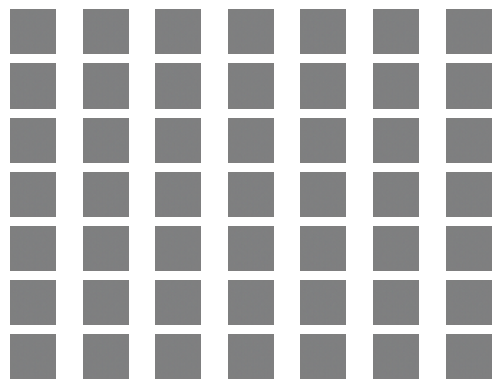

In [ ]:
laten_dim = 100
model = define_generator(laten_dim)
n_sample = 49
X, _ = generate_fake_samples(model, laten_dim, n_samples=n_sample)
X = (X + 1) / 2.0
for i in range(n_sample):
  plt.subplot(7,7,1+i)
  plt.axis('off')
  plt.imshow(X[i])
plt.show()

In [ ]:
def define_gen(g_model,d_model):
  d_model.trainable = False
  model = Sequential()
  model.add(g_model)
  model.add(d_model)
  opt = Adam(learning_rate=0.0002, beta_1=0.5)
  model.compile(loss='binary_crossentropy', optimizer=opt)
  return model


In [ ]:
laten_dim = 100
d_model = define_discriminator()
g_model = define_generator(laten_dim)
gan_model = define_gen(g_model,d_model)
gan_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 32, 32, 3)      │     1,466,115 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 1)              │       522,497 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,988,612 (7.59 MB)

 Trainable params: 1,466,115 (5.59 MB)

 Non-trainable params: 522,497 (1.99 MB)

In [ ]:
def train(g_model,d_model,gan_model,dataset,laten_dim,n_epochs=10,n_batch=128):
  bat_per_epoch = int(dataset.shape[0] / n_batch)
  half_batch = int(n_batch / 2)
  for i in range(n_epochs):
    for j in range(bat_per_epoch):
      X_real, y_real = generate_real_samples(dataset, half_batch)
      d_loss1, _ = d_model.train_on_batch(X_real, y_real)
      X_fake, y_fake = generate_fake_samples(g_model, laten_dim, half_batch)
      d_loss2, _ = d_model.train_on_batch(X_fake, y_fake)
      X_gan = generate_latent_points(laten_dim, n_batch)
      y_gan = np.ones((n_batch, 1))
      g_loss = gan_model.train_on_batch(X_gan, y_gan)
      print('>%d, %d/%d, d1=%.3f, d2=%.3f g=%.3f' % (i+1, j+1, bat_per_epoch, d_loss1, d_loss2, g_loss))
      if (i+1) % 10 == 0:
        summarize_performance(i, g_model, d_model, dataset, laten_dim)

In [ ]:

def summarize_performance(epoch, g_model, d_model, dataset, laten_dim, n_samples=150):
  X_real, y_real = generate_real_samples(dataset, n_samples)
  _, acc_real = d_model.evaluate(X_real, y_real, verbose=0)
  x_fake, y_fake = generate_fake_samples(g_model, laten_dim, n_samples)
  _, acc_fake = d_model.evaluate(x_fake, y_fake, verbose=0)
  print('>Accuracy real: %.0f%%, fake: %.0f%%' % (acc_real*100, acc_fake*100))
  save_plot(x_fake, epoch)
  filename = 'generator_model_%03d.h5' % (epoch + 1)
  g_model.save(filename)

In [ ]:
def save_plot(examples, epoch, n=7):
  examples = (examples +1) / 2.0
  for i in range(n*n):
    plt.subplot(n, n, 1+i)
    plt.axis('off')
    plt.imshow(examples[i])
  filename = 'generated_plot_e%03d.png' % (epoch+1)
  plt.savefig(filename)
  plt.close()

In [ ]:

train(g_model,d_model, gan_model, dataset,laten_dim,n_epochs=100,n_batch=128)

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
>1, 1/390, d1=0.679, d2=0.686 g=0.693
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 331ms/step
>1, 2/390, d1=0.685, d2=0.687 g=0.693
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
>1, 3/390, d1=0.686, d2=0.688 g=0.692
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
>1, 4/390, d1=0.687, d2=0.688 g=0.691
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 375ms/step
>1, 5/390, d1=0.687, d2=0.688 g=0.690
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
>1, 6/390, d1=0.687, d2=0.689 g=0.689
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
>1, 7/390, d1=0.689, d2=0.690 g=0.688
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 378ms/step
>1, 8/390, d1=0.689, d2=0.691 g=0.686
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
>1, 9/390, d1=0.690, d2=0.692 g=0.683
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
>1, 10/390, d1=0.692, d2=0.694 g=0.679
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 343ms/step
>1, 11/390, d1=0.694, d2=0.697 g=0.675
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
>1, 12/390, d1=0.696, d2=0.700 g=0.669
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
>1, 13/390, d1=0.699, d2=0.704 g=0